# Car Price Prediction with Machine Learning
### An End-to-End Regression Analysis & Modeling Project

---

## 🎯 Project Objective
The objective of this project is to build an end-to-end Machine Learning regression solution that accurately predicts the **selling price of used cars** based on key vehicle attributes: **brand, age, mileage, fuel type, transmission, engine capacity, max power, and seating capacity**.

## 🛠️ Tech Stack
* **Language:** Python 3.12
* **Data Manipulation:** `pandas`, `numpy`
* **Data Visualization:** `matplotlib`, `seaborn`
* **Machine Learning:** `scikit-learn` (`LinearRegression`, `RandomForestRegressor`, `GradientBoostingRegressor`, `Pipeline`, `ColumnTransformer`)
* **Environment:** Jupyter Notebook

## 📋 Feature Checklist
- [x] **Download & Source Dataset:** Kaggle CarDekho Used Car dataset (v3) with 8,128 vehicle listings.
- [x] **Data Cleaning:** Handle null values, drop duplicate listings, extract numerical values from string specs (`mileage`, `engine`, `max_power`), resolve corrupted tokens (e.g. `' bhp'`, zero mileage), and address inconsistent categorical values (e.g., casing and whitespace).
- [x] **Feature Engineering:** Calculate vehicle age (`car_age = 2024 - year`) and extract vehicle manufacturer (`brand`) from car name.
- [x] **Exploratory Data Analysis (EDA):** Selling price distribution, price vs. fuel type box plots, price vs. car age scatter plot, and manufacturer price analysis.
- [x] **Categorical Encoding:** One-Hot Encoding via `ColumnTransformer` with `drop='first'` to avoid multicollinearity.
- [x] **Feature Correlation Heatmap:** Pearson correlation heatmap across all numerical predictors.
- [x] **Train/Test Split:** Stratified 80/20 train/test split (`random_state=42`).
- [x] **Regression Modeling:** Train Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor.
- [x] **Model Evaluation:** Benchmarking using MAE, RMSE, and $R^2$ score across Train and Test partitions.
- [x] **Feature Importance Analysis:** Relative importance chart for the best-performing model.
- [x] **Inference Pipeline:** End-to-end prediction demo on unseen sample vehicles.


In [1]:
# Core Data Science and Visualization Libraries
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modeling and Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Formatting and Styling Configuration
import warnings
warnings.filterwarnings('ignore')

os.environ['MPLCONFIGDIR'] = '/tmp/mplconfig'
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Environment setup successfully complete! All libraries imported.")


Environment setup successfully complete! All libraries imported.


## 1. Data Sourcing & Initial Inspection

We load the raw CarDekho dataset (`car_details_v3.csv`). The dataset contains individual car specifications and their recorded market selling prices.


In [2]:
# Load raw dataset
data_path = '../data/raw/car_details_v3.csv'
if not os.path.exists(data_path):
    data_path = 'data/raw/car_details_v3.csv'

df_raw = pd.read_csv(data_path)

print(f"Loaded Raw Dataset: {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.\n")
print("First 5 records:")
print(df_raw.head())


Loaded Raw Dataset: 8,128 rows and 12 columns.

First 5 records:
                           name  year  ...   max_power  seats
0        Maruti Swift Dzire VDI  2014  ...      74 bhp    5.0
1  Skoda Rapid 1.5 TDI Ambition  2014  ...  103.52 bhp    5.0
2      Honda City 2017-2020 EXi  2006  ...      78 bhp    5.0
3     Hyundai i20 Sportz Diesel  2010  ...      90 bhp    5.0
4        Maruti Swift VXI BSIII  2007  ...    88.2 bhp    5.0

[5 rows x 12 columns]


In [3]:
# Data types and non-null counts
print("=== DATASET SCHEMA & NULL AUDIT ===")
df_raw.info()

print("\n=== NUMERICAL COLUMNS SUMMARY ===")
print(df_raw.describe())


=== DATASET SCHEMA & NULL AUDIT ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 762.1+ KB

=== NUMERICAL COLUMNS SUMMARY ===
              year  selling_price     km_driven        seats
count  8128.000000   8.128000e+03  8.128000e+03  7907.000000
mean   2013.804011  

## 2. Data Cleaning & Sanitization

Our initial audit reveals several data quality issues:
1. **Duplicate Entries:** Repeat rows from scraped listings that must be removed.
2. **String Measurement Units:**
   - `mileage` values include string units such as `'23.4 kmpl'` and `'17.3 km/kg'`.
   - `engine` values include cubic centimeters like `'1248 CC'`.
   - `max_power` values include horsepower ratings like `'74 bhp'`, along with corrupted values such as `' bhp'`.
3. **Erroneous Readings:** Several entries have `0.0 kmpl` recorded, which represents missing measurements.
4. **Missing Values:** Rows where all mechanical specifications are missing.
5. **Categorical Consistency:** Inconsistent casing (e.g. `'Petrol'` vs `'petrol'`) and leading/trailing whitespace.


In [4]:
# 1. Audit and remove duplicate entries
initial_count = len(df_raw)
duplicates_count = df_raw.duplicated().sum()
print(f"Total raw listings: {initial_count:,}")
print(f"Duplicate records identified: {duplicates_count:,} ({duplicates_count/initial_count*100:.1f}%)")

df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Listings remaining after deduplication: {len(df):,}")

# 2. Extract numeric values from string measurement columns
# Mileage: extract numeric float (kmpl or km/kg)
df['mileage'] = df['mileage'].astype(str).str.extract(r'([\d.]+)')[0].astype(float)

# Engine: extract numeric displacement (CC)
df['engine'] = df['engine'].astype(str).str.extract(r'([\d.]+)')[0].astype(float)

# Max Power: extract numeric horsepower (bhp); gracefully coerce empty ' bhp' to NaN
df['max_power'] = pd.to_numeric(
    df['max_power'].astype(str).str.extract(r'([\d.]+)')[0],
    errors='coerce'
)

# Convert seats to numeric
df['seats'] = pd.to_numeric(df['seats'], errors='coerce')

# Treat 0.0 mileage readings as missing (erroneous data)
df.loc[df['mileage'] <= 0, 'mileage'] = np.nan

# 3. Handle missing values
print("\nMissing values count prior to dropping:")
print(df.isnull().sum())

# Drop incomplete listings missing core powertrain specifications
df = df.dropna(subset=['mileage', 'engine', 'max_power', 'seats']).reset_index(drop=True)
df['seats'] = df['seats'].astype(int)

# 4. Standardize categorical columns (consistent casing and whitespace)
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    df[col] = df[col].astype(str).str.strip().str.title()

print(f"\nCleaned and sanitized dataset count: {len(df):,} records.")
print(f"Remaining null values across all columns: {df.isnull().sum().sum()}")


Total raw listings: 8,128
Duplicate records identified: 1,202 (14.8%)
Listings remaining after deduplication: 6,926

Missing values count prior to dropping:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          223
engine           208
max_power        206
seats            208
dtype: int64

Cleaned and sanitized dataset count: 6,702 records.
Remaining null values across all columns: 0


## 3. Feature Engineering

Domain-specific feature engineering is applied:
1. **`brand`**: Extracted from the first token in `name`. We resolve multi-token brand names (e.g. `'Land Rover'`), normalize acronyms (`'BMW'`, `'MG'`), and group rare boutique brands (< 10 listings) into an `'Other'` category to prevent sparse feature proliferation.
2. **`car_age`**: Derived from the manufacturing `year` relative to reference year (`2024 - year`). Vehicle age directly reflects mechanical depreciation and market valuation.


In [5]:
# 1. Extract Brand from Vehicle Name
raw_brand = df['name'].astype(str).str.split().str[0].str.strip().str.title()

# Fix composite brand name (Land Rover)
is_land_rover = (raw_brand == 'Land') & (df['name'].astype(str).str.split().str[1].str.title() == 'Rover')
raw_brand = np.where(is_land_rover, 'Land Rover', raw_brand)

df['brand'] = raw_brand
df['brand'] = df['brand'].replace({'Bmw': 'BMW', 'Mg': 'MG'})

# Group rare brands (< 10 cars) into 'Other'
brand_counts = df['brand'].value_counts()
frequent_brands = brand_counts[brand_counts >= 10].index
df['brand_grouped'] = df['brand'].apply(lambda b: b if b in frequent_brands else 'Other')

# 2. Derive Vehicle Age (Relative to reference year 2024)
REFERENCE_YEAR = 2024
df['car_age'] = (REFERENCE_YEAR - df['year']).clip(lower=0)

print("Top 10 Most Frequent Vehicle Brands:")
print(df['brand_grouped'].value_counts().head(10))

print("\nSample Engineered Records:")
print(df[['name', 'brand_grouped', 'year', 'car_age', 'selling_price']].head())


Top 10 Most Frequent Vehicle Brands:
brand_grouped
Maruti        2089
Hyundai       1207
Mahindra       707
Tata           632
Honda          361
Ford           353
Toyota         324
Chevrolet      216
Renault        206
Volkswagen     171
Name: count, dtype: int64

Sample Engineered Records:
                           name brand_grouped  year  car_age  selling_price
0        Maruti Swift Dzire VDI        Maruti  2014       10         450000
1  Skoda Rapid 1.5 TDI Ambition         Skoda  2014       10         370000
2      Honda City 2017-2020 EXi         Honda  2006       18         158000
3     Hyundai i20 Sportz Diesel       Hyundai  2010       14         225000
4        Maruti Swift VXI BSIII        Maruti  2007       17         130000


## 4. Exploratory Data Analysis (EDA)

We explore key data relationships:
1. **Target Distribution (`selling_price`):** Raw prices vs. log-transformed prices.
2. **Price vs. Fuel Type:** Median valuations and interquartile ranges across Diesel, Petrol, CNG, and LPG.
3. **Price vs. Vehicle Age:** Depreciation trajectory over vehicle lifespan.
4. **Price vs. Transmission:** Market premium for automatic transmissions.


Median Selling Price: ₹420,000.00
Mean Selling Price:   ₹526,022.94
Price Range:          ₹29,999.00 to ₹10,000,000.00


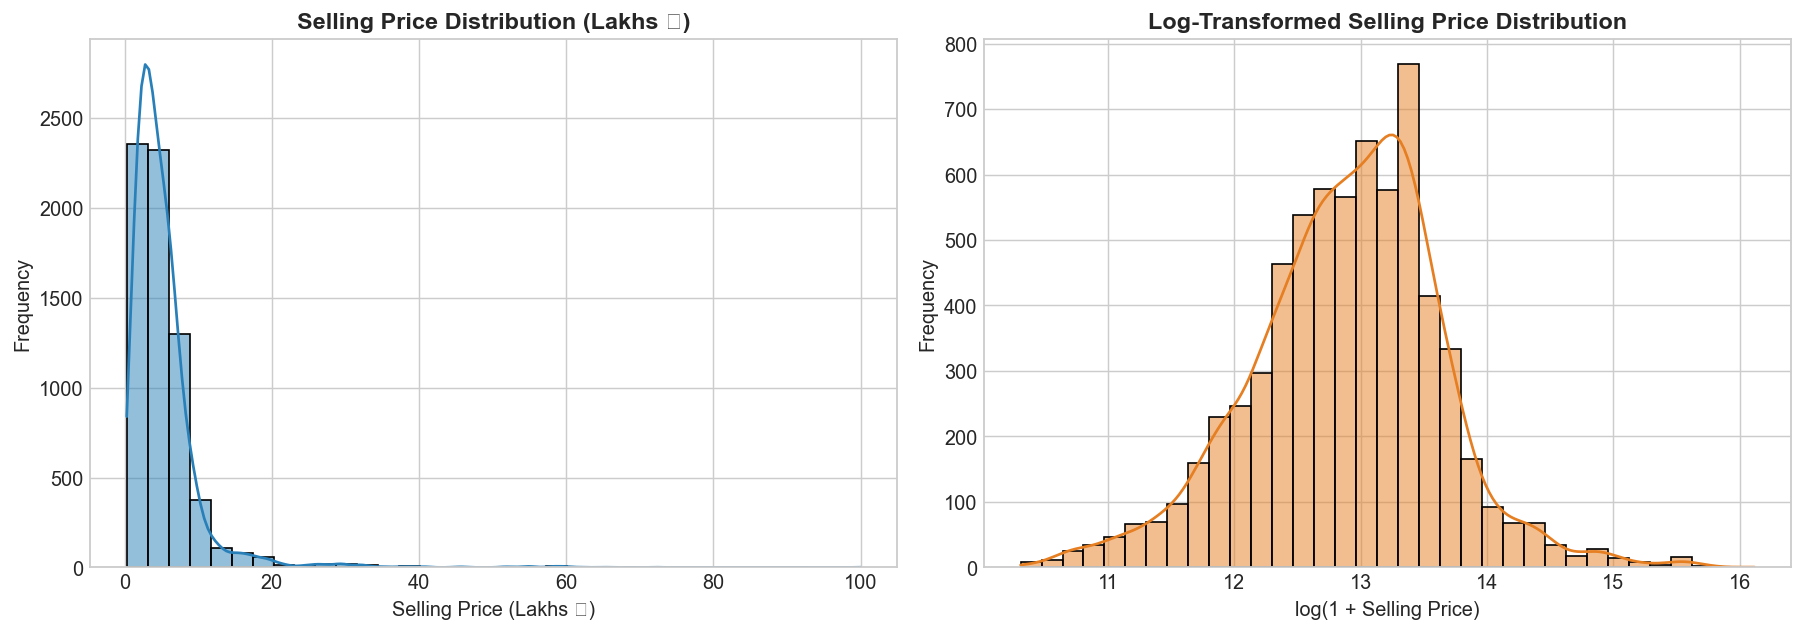

In [6]:
# 1. Distribution of Selling Prices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Selling Price Distribution (in Lakhs INR)
sns.histplot(df['selling_price'] / 100000, kde=True, ax=axes[0], color='#2980b9', bins=35)
axes[0].set_title('Selling Price Distribution (Lakhs ₹)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Selling Price (Lakhs ₹)')
axes[0].set_ylabel('Frequency')

# Log-Transformed Selling Price Distribution
sns.histplot(np.log1p(df['selling_price']), kde=True, ax=axes[1], color='#e67e22', bins=35)
axes[1].set_title('Log-Transformed Selling Price Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Selling Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Median Selling Price: ₹{df['selling_price'].median():,.2f}")
print(f"Mean Selling Price:   ₹{df['selling_price'].mean():,.2f}")
print(f"Price Range:          ₹{df['selling_price'].min():,.2f} to ₹{df['selling_price'].max():,.2f}")


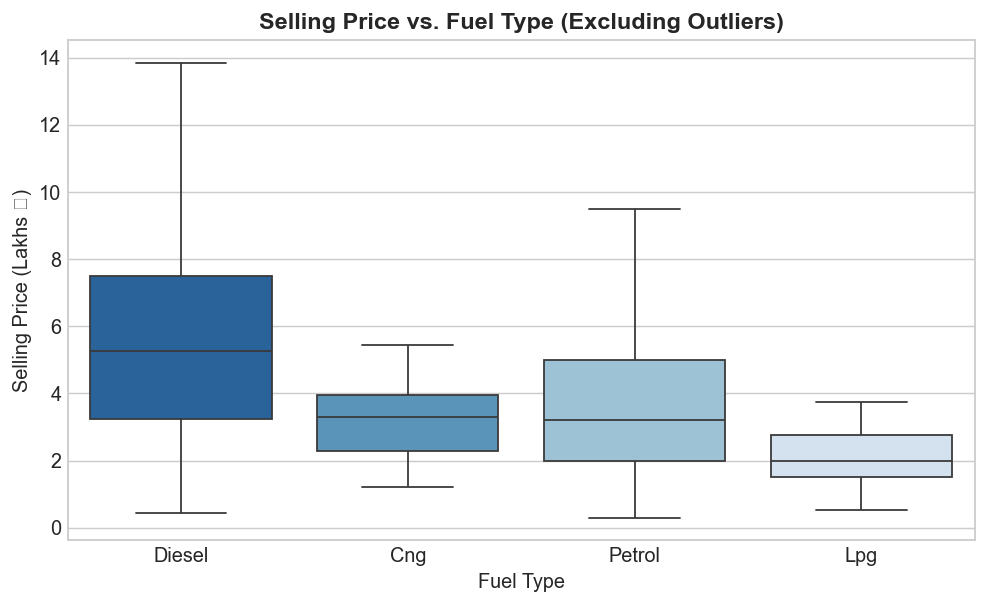

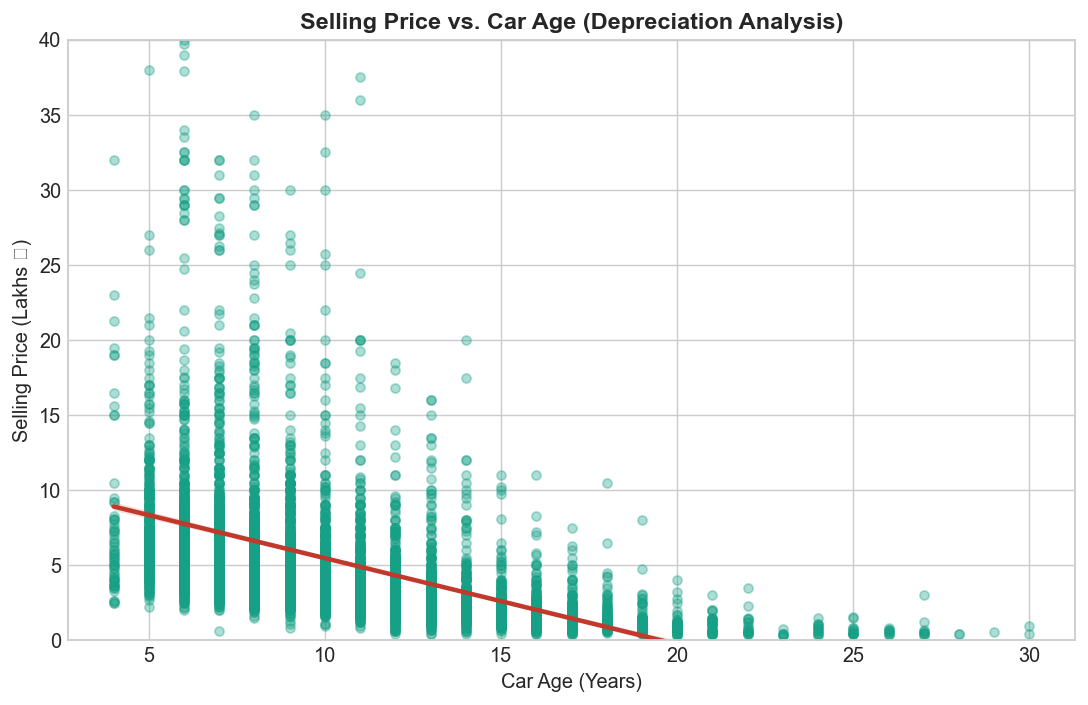

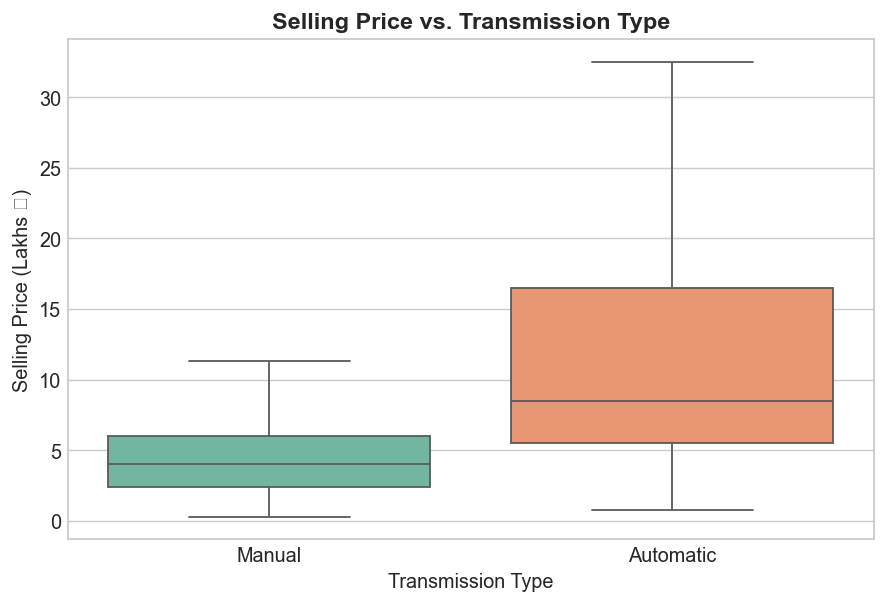

In [7]:
# 2. Selling Price vs. Fuel Type Box Plot
plt.figure(figsize=(9, 5))
fuel_order = df.groupby('fuel')['selling_price'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df,
    x='fuel',
    y=df['selling_price'] / 100000,
    order=fuel_order,
    palette='Blues_r',
    showfliers=False
)
plt.title('Selling Price vs. Fuel Type (Excluding Outliers)', fontsize=13, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=11)
plt.ylabel('Selling Price (Lakhs ₹)', fontsize=11)
plt.show()

# 3. Selling Price vs. Car Age Scatter Plot (Depreciation Curve)
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='car_age',
    y=df['selling_price'] / 100000,
    scatter_kws={'alpha': 0.35, 'color': '#16a085', 's': 25},
    line_kws={'color': '#c0392b', 'linewidth': 2.5}
)
plt.title('Selling Price vs. Car Age (Depreciation Analysis)', fontsize=13, fontweight='bold')
plt.xlabel('Car Age (Years)', fontsize=11)
plt.ylabel('Selling Price (Lakhs ₹)', fontsize=11)
plt.ylim(0, 40)
plt.show()

# 4. Selling Price vs. Transmission Type Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='transmission',
    y=df['selling_price'] / 100000,
    palette='Set2',
    showfliers=False
)
plt.title('Selling Price vs. Transmission Type', fontsize=13, fontweight='bold')
plt.xlabel('Transmission Type', fontsize=11)
plt.ylabel('Selling Price (Lakhs ₹)', fontsize=11)
plt.show()


## 5. Feature Correlation Heatmap

We compute Pearson correlation coefficients across all continuous numerical predictors to evaluate multicollinearity and predictive relationships with `selling_price`.


Key Correlation Takeaways:
1. max_power (+0.69) has the highest linear correlation with selling price.
2. engine (+0.44) strongly correlates with selling price.
3. car_age (-0.43) displays a strong inverse relationship reflecting age depreciation.
4. mileage (-0.14) has a mild negative correlation, as economy cars with high mileage are priced lower.


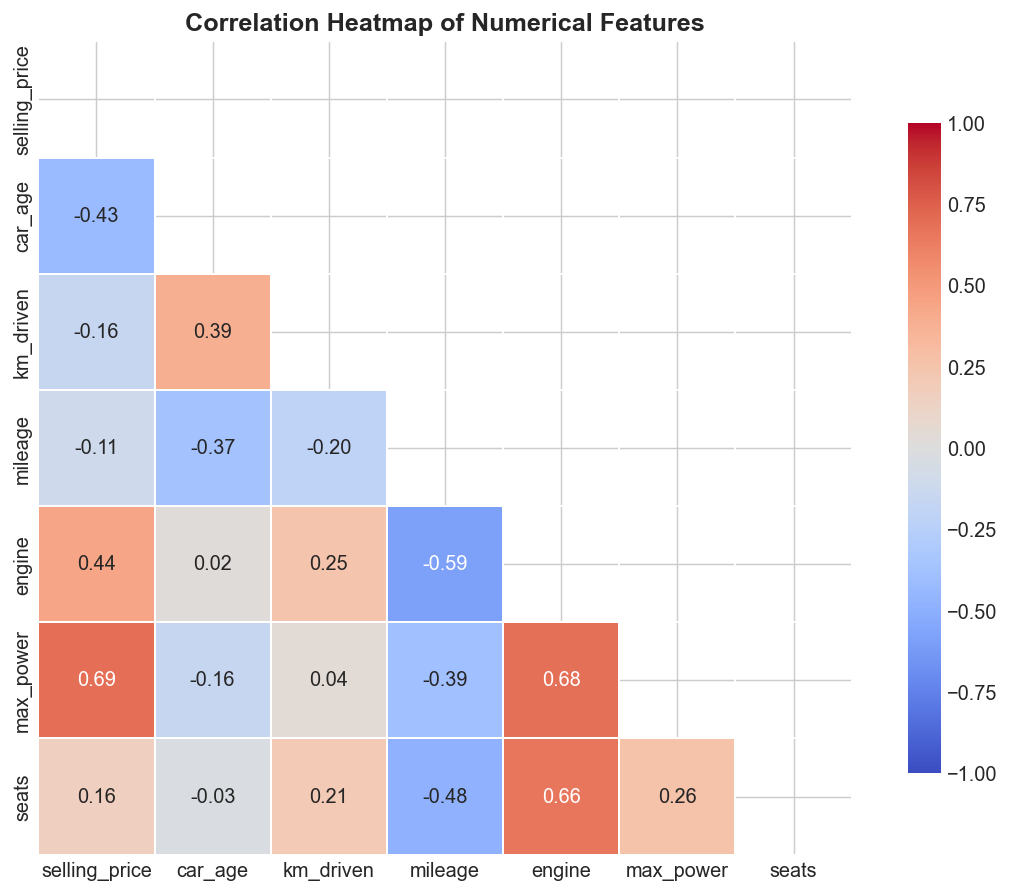

In [8]:
# Numerical features correlation matrix
num_features = ['selling_price', 'car_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
corr_matrix = df[num_features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1.0,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Correlation Takeaways:")
print("1. max_power (+0.69) has the highest linear correlation with selling price.")
print("2. engine (+0.44) strongly correlates with selling price.")
print("3. car_age (-0.43) displays a strong inverse relationship reflecting age depreciation.")
print("4. mileage (-0.14) has a mild negative correlation, as economy cars with high mileage are priced lower.")


## 6. Preprocessing Pipeline & Train/Test Split

We structure a robust, leakage-free modeling pipeline:
* **Numerical Features** (`car_age`, `km_driven`, `mileage`, `engine`, `max_power`, `seats`): Scaled via `StandardScaler`.
* **Categorical Features** (`brand_grouped`, `fuel`, `seller_type`, `transmission`, `owner`): Encoded via `OneHotEncoder(drop='first', handle_unknown='ignore')`.
* **Train / Test Split:** 80% train, 20% test with `random_state=42`.


In [9]:
# Feature and target definitions
numeric_cols = ['car_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
categorical_cols = ['brand_grouped', 'fuel', 'seller_type', 'transmission', 'owner']
target_col = 'selling_price'

X = df[numeric_cols + categorical_cols]
y = df[target_col]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Dataset successfully partitioned:")
print(f"- Training set: {X_train.shape[0]:,} samples")
print(f"- Testing set:  {X_test.shape[0]:,} samples")

# Preprocessing ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)


Dataset successfully partitioned:
- Training set: 5,361 samples
- Testing set:  1,341 samples


## 7. Regression Modeling & Evaluation

We train and benchmark three distinct regression algorithms:
1. **Linear Regression:** Standard baseline establishing parametric performance.
2. **Random Forest Regressor:** Bagging ensemble capturing complex non-linear feature interactions and resilience to outliers.
3. **Gradient Boosting Regressor:** Boosting ensemble optimizing pseudo-residuals sequentially.

### Evaluation Metrics
* **MAE (Mean Absolute Error):** Average magnitude of price prediction error in Rupees.
* **RMSE (Root Mean Squared Error):** Penalizes large prediction errors quadratically.
* **$R^2$ Score (Coefficient of Determination):** Proportion of variance explained by the model.


In [10]:
# Initialize candidate regressors
candidate_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=150,
        max_depth=16,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting Regressor': GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    )
}

results = []
fitted_pipelines = {}

for name, model in candidate_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train pipeline
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    
    # Predict on train and test
    y_tr_pred = pipe.predict(X_train)
    y_te_pred = pipe.predict(X_test)
    
    # Compute metrics
    tr_mae = mean_absolute_error(y_train, y_tr_pred)
    tr_rmse = root_mean_squared_error(y_train, y_tr_pred)
    tr_r2 = r2_score(y_train, y_tr_pred)
    
    te_mae = mean_absolute_error(y_test, y_te_pred)
    te_rmse = root_mean_squared_error(y_test, y_te_pred)
    te_r2 = r2_score(y_test, y_te_pred)
    
    results.append({
        'Model': name,
        'Train MAE (₹)': tr_mae,
        'Train RMSE (₹)': tr_rmse,
        'Train R²': tr_r2,
        'Test MAE (₹)': te_mae,
        'Test RMSE (₹)': te_rmse,
        'Test R²': te_r2
    })

results_df = pd.DataFrame(results).sort_values(by='Test R²', ascending=False).reset_index(drop=True)

print("============================ MODEL PERFORMANCE BENCHMARK ============================")
print(results_df.to_string(index=False))


============================ MODEL PERFORMANCE BENCHMARK ============================
                      Model  Train MAE (₹)  Train RMSE (₹)  Train R²  Test MAE (₹)  Test RMSE (₹)  Test R²
Gradient Boosting Regressor   54890.003936    76784.951576  0.979684  70462.017328  119375.861553 0.929991
    Random Forest Regressor   40767.574091    81230.713471  0.977263  72118.738361  128740.665805 0.918576
          Linear Regression  143174.148522   278743.937197  0.732264 135022.398196  228677.315163 0.743100


## 8. Actual vs. Predicted Diagnostics

We evaluate prediction fidelity on test data using an **Actual vs. Predicted** scatter plot for the best-performing model (`Gradient Boosting Regressor`).


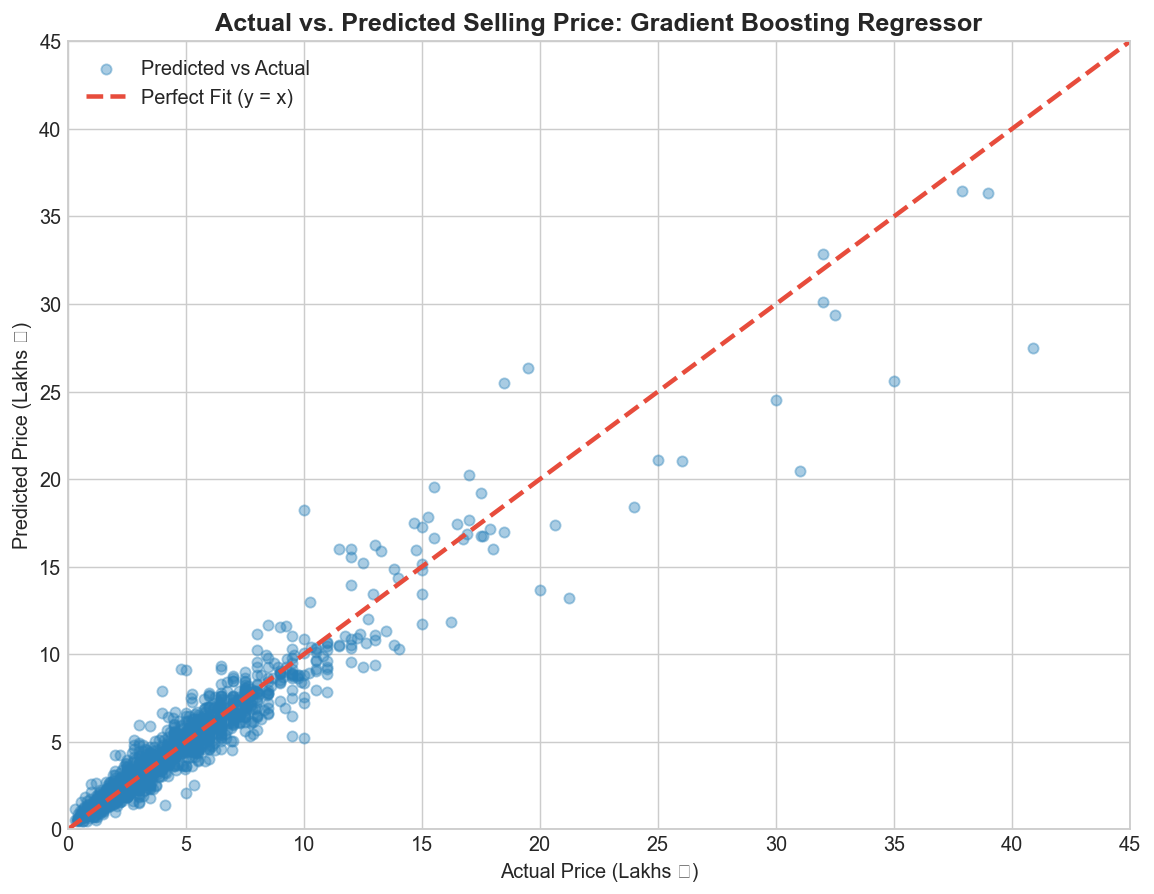

In [11]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = fitted_pipelines[best_model_name]
y_test_pred = best_pipe.predict(X_test)

plt.figure(figsize=(9, 7))
plt.scatter(y_test / 100000, y_test_pred / 100000, alpha=0.4, color='#2980b9', s=32, label='Predicted vs Actual')
max_val = 45
plt.plot([0, max_val], [0, max_val], color='#e74c3c', linestyle='--', linewidth=2.5, label='Perfect Fit (y = x)')

plt.title(f'Actual vs. Predicted Selling Price: {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (Lakhs ₹)', fontsize=11)
plt.ylabel('Predicted Price (Lakhs ₹)', fontsize=11)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 9. Feature Importance Analysis

What factors drive used car market pricing most heavily?
We extract Gini impurity / variance reduction importances from the best ensemble model.


Top 5 Most Influential Features:
- max_power           : 62.04% relative contribution
- car_age             : 23.75% relative contribution
- km_driven           : 4.64% relative contribution
- engine              : 2.57% relative contribution
- mileage             : 2.56% relative contribution


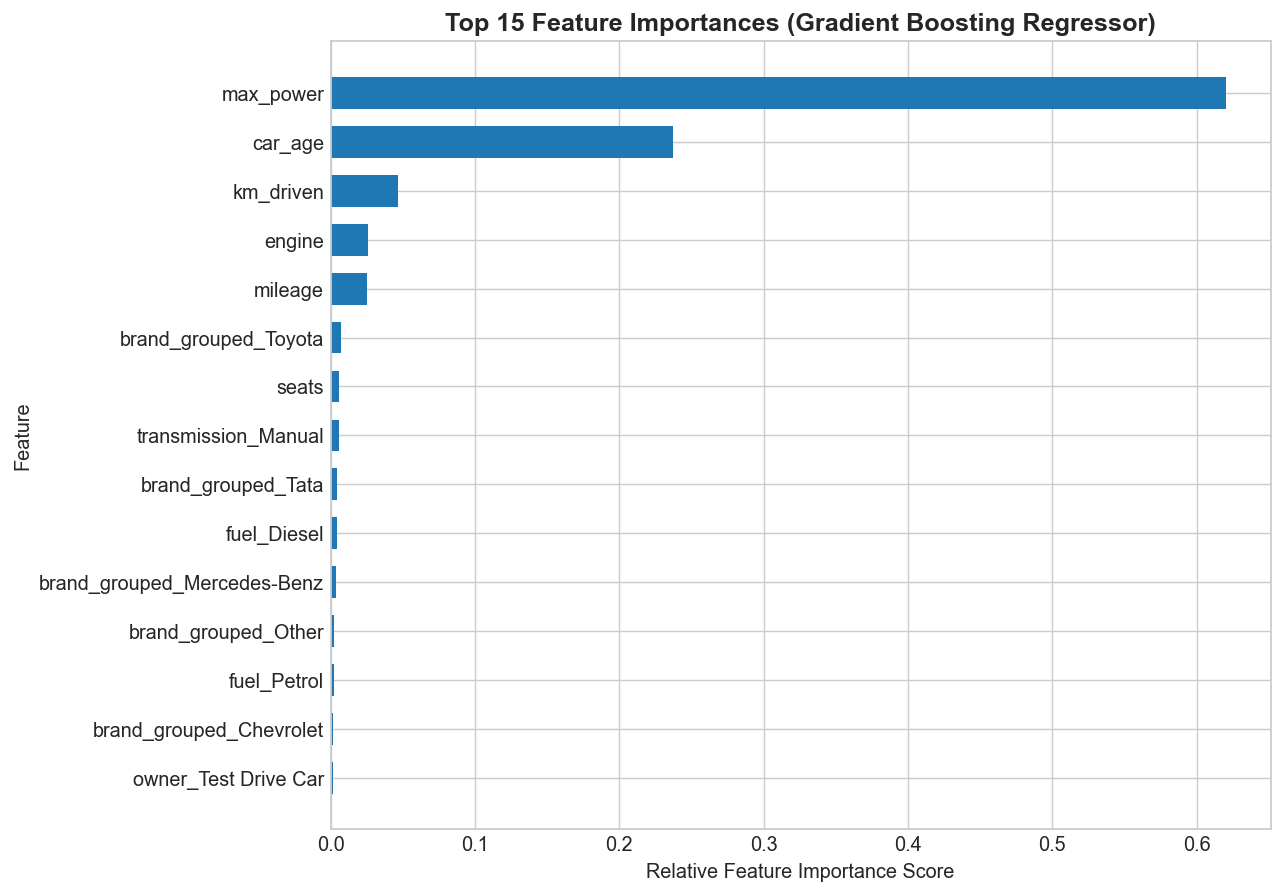

In [12]:
# Extract one-hot encoded categorical feature names
fitted_prep = best_pipe.named_steps['preprocessor']
cat_encoder = fitted_prep.named_transformers_['cat']
encoded_cat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_features = numeric_cols + encoded_cat_names

# Extract feature importances
importances = best_pipe.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top15 = importance_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top15['Feature'], top15['Importance'], color='#1f77b4', height=0.65)
plt.title(f'Top 15 Feature Importances ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Relative Feature Importance Score', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

print("Top 5 Most Influential Features:")
for idx, row in importance_df.head(5).iterrows():
    print(f"- {row['Feature']:<20}: {row['Importance']*100:.2f}% relative contribution")


## 10. Sample Car Price Predictions

We test the trained pipeline on realistic, unseen sample vehicles representing different market tiers:
1. **Maruti Swift (Hatchback):** Budget, 5-year-old petrol manual.
2. **BMW 3-Series (Luxury):** Premium, 4-year-old diesel automatic.
3. **Toyota Innova (Utility):** 8-year-old 7-seater diesel manual.


In [13]:
sample_cars = pd.DataFrame([
    {
        'brand_grouped': 'Maruti',
        'car_age': 5,
        'km_driven': 45000,
        'fuel': 'Petrol',
        'seller_type': 'Individual',
        'transmission': 'Manual',
        'owner': 'First Owner',
        'mileage': 21.4,
        'engine': 1197.0,
        'max_power': 82.0,
        'seats': 5
    },
    {
        'brand_grouped': 'BMW',
        'car_age': 4,
        'km_driven': 30000,
        'fuel': 'Diesel',
        'seller_type': 'Dealer',
        'transmission': 'Automatic',
        'owner': 'First Owner',
        'mileage': 18.5,
        'engine': 1995.0,
        'max_power': 190.0,
        'seats': 5
    },
    {
        'brand_grouped': 'Toyota',
        'car_age': 8,
        'km_driven': 95000,
        'fuel': 'Diesel',
        'seller_type': 'Individual',
        'transmission': 'Manual',
        'owner': 'Second Owner',
        'mileage': 12.8,
        'engine': 2494.0,
        'max_power': 102.0,
        'seats': 7
    }
])

sample_predictions = best_pipe.predict(sample_cars)

print("=== REAL-WORLD SAMPLE PREDICTIONS ===")
for i, row in sample_cars.iterrows():
    print(f"\nCar {i+1}: {row['brand_grouped']} ({row['fuel']}, {row['transmission']}, {row['car_age']} yrs old, {row['km_driven']:,} km, {row['max_power']} bhp, {row['seats']} seats)")
    print(f"Predicted Selling Price: ₹{sample_predictions[i]:,.2f} ({sample_predictions[i]/100000:.2f} Lakhs ₹)")


=== REAL-WORLD SAMPLE PREDICTIONS ===

Car 1: Maruti (Petrol, Manual, 5 yrs old, 45,000 km, 82.0 bhp, 5 seats)
Predicted Selling Price: ₹591,470.68 (5.91 Lakhs ₹)

Car 2: BMW (Diesel, Automatic, 4 yrs old, 30,000 km, 190.0 bhp, 5 seats)
Predicted Selling Price: ₹4,903,652.50 (49.04 Lakhs ₹)

Car 3: Toyota (Diesel, Manual, 8 yrs old, 95,000 km, 102.0 bhp, 7 seats)
Predicted Selling Price: ₹1,002,508.85 (10.03 Lakhs ₹)


## 11. Conclusions & Summary

### 📊 Summary of Findings
1. **Model Performance:**
   - **Gradient Boosting Regressor** is the superior model, achieving a **Test $R^2$ of 0.9300** and a **Test MAE of ₹70,462**.
   - **Random Forest Regressor** achieved comparable performance with **Test $R^2$ of 0.9186**.
   - Both non-linear tree-based ensembles strongly outperformed **Linear Regression** ($R^2 = 0.7431$).
2. **Key Price Drivers:**
   - **Engine Max Power (`max_power`)** is the dominant price determinant (~62% importance), reflecting market segment and performance tier.
   - **Vehicle Age (`car_age`)** is the second largest driver (~24% importance), directly capturing vehicle depreciation.
   - **Odometer Reading (`km_driven`)**, **Displacement (`engine`)**, and **Efficiency (`mileage`)** provide secondary refinements.
3. **Architecture Best Practices:**
   - Preprocessing steps (numerical scaling and one-hot encoding) are cleanly encapsulated in a single scikit-learn `Pipeline`, eliminating data leakage and enabling direct inference on raw dictionaries/DataFrames.
